In [10]:
from langgraph.graph import StateGraph,START,END 
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv
from typing import TypedDict
from pydantic import BaseModel , Field

In [11]:
class QuadState(TypedDict):
    a: int
    b:int
    c:int

    equation: str
    disriminant: int
    result: str

In [23]:
def show_equation(state: QuadState) -> QuadState:
    equation = f'{state['a']}x2{state['b']}x {state['c']}'
    
    return {'equation' : equation}

def calculate_discriminant(state: QuadState) -> QuadState:
    discriminant = state['b']**2 - (4 * state['a'] * state['c'])
    return {'discriminant': discriminant}


In [24]:
graph = StateGraph(QuadState)

graph.add_node('Show the equation' ,show_equation)
graph.add_node('Calculate the discriminant', calculate_discriminant)


graph.add_edge(START, 'Show the equation')
graph.add_edge('Show the equation', 'Calculate the discriminant')
graph.add_edge('Calculate the discriminant', END) 

workflow = graph.compile()


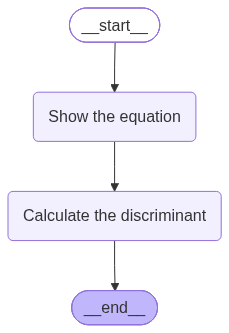

In [25]:
workflow

In [26]:
initial_state = {
    'a': 4,
    'b': -5,
    'c': -4
}
workflow.invoke(initial_state)

{'a': 4, 'b': -5, 'c': -4, 'equation': '4x2-5x -4'}